In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# the .data file has no header, they're defined and assigned to this variable, obtained from the accompanying doc
columns = ["checking_account_status", "duration_months", "credit_history", "purpose",
           "credit_amount", "savings_account", "employment_since", "installment_rate",
           "personal_status_sex", "other_debtors", "residence_since", "property",
           "age", "other_installment_plans", "housing", "existing_credits",
           "job", "dependents", "telephone", "foreign_worker", "credit_risk"]

df = pd.read_csv("data/raw/german.data",
                 sep = " ",
                 header = None,
                 names = columns)

df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
# remapping credit risk 1/2 -> 0/1 for ease
df["credit_risk"] = df["credit_risk"].map({1: 0, 2: 1}) # 1 is a default, 0 is good

In [7]:
# count each unique value in this column, return each as a proprtion of total
df["credit_risk"].value_counts(normalize = True)

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64

In banking, defaults are in the minority. This imbalance might be misleading if I only use accuracy as a metric. A model that always predicts 'good' would still score ~ 70%. Recall and precision are better to use.

In [8]:
# let's take a closer look at the data
df.info()
df.describe()
df["purpose"].value_counts()
df["checking_account_status"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

checking_account_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

The categorical codes don't make sense now. Will map them later

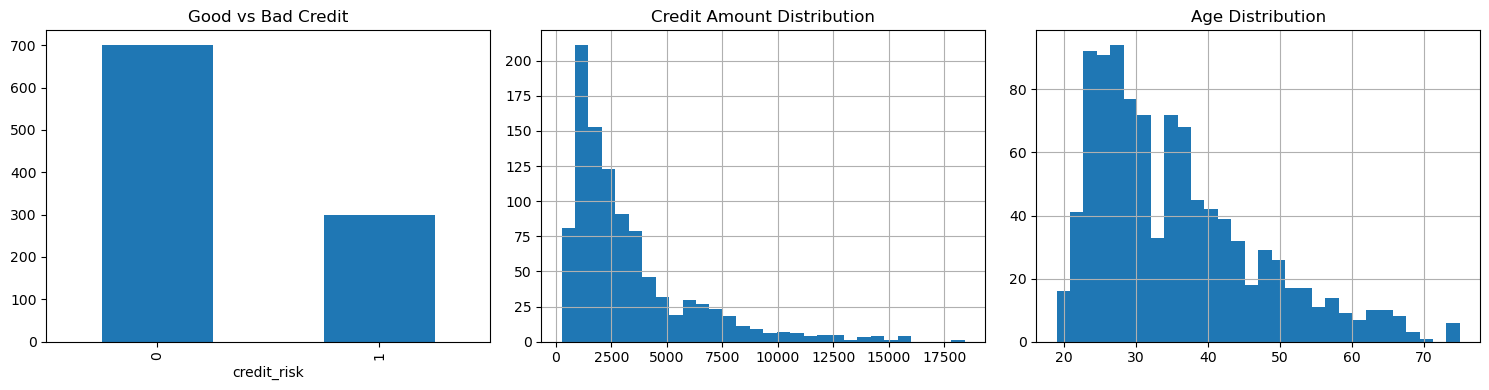

In [9]:
# a few plots to explore the distributions and imbalance
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

df["credit_risk"].value_counts().plot(kind = "bar",
                                      ax = axes[0], 
                                      title = "Good vs Bad Credit")
df["credit_amount"].hist(bins = 30, 
                         ax = axes[1])
axes[1].set_title("Credit Amount Distribution") # .hist() doesn't take title arguments

df["age"].hist(bins = 30, 
               ax = axes[2])
axes[2].set_title("Age Distribution")

plt.tight_layout()
plt.savefig("visualisations/class_balance_and_distributions.png")
plt.show()

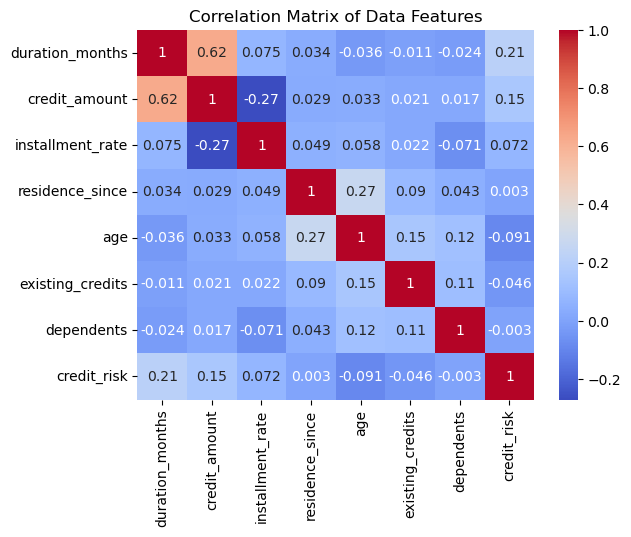

In [10]:
# a correlation matrix heatmap to explore relationships between the numeric features and the target
numeric_cols = ["duration_months", "credit_amount", "installment_rate",
               "residence_since", "age", "existing_credits", "dependents"]
sns.heatmap(df[numeric_cols + ["credit_risk"]].corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix of Data Features")
plt.savefig("visualisations/correlation_matrix_of_data_features.png")
plt.show()

1. duration_months and credit_amount have the highest positive correlation, as expected
2. duration_months and credit_risk are weakly positively correlated

In [11]:
df.isnull().sum()

checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

No null values in this dataset

In [12]:
# encoding for ordinal data
# this preserves the "more account activity is better" implication
ordinal_maps = {"checking_account_status": {"A14": 0, "A11": 1, "A12": 2, "A13": 3},
                "savings_account": {"A65": 0, "A61": 1, "A62": 2, "A63": 3, "A64": 4},
                "employment_since": {"A71": 0, "A72": 1, "A73": 2, "A74": 3, "A75": 4}}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

In [13]:
df[["checking_account_status", "savings_account", "employment_since"]].head()

,checking_account_status,savings_account,employment_since
0,1,0,4
1,2,1,2
2,0,1,3
3,1,1,3
4,1,1,2


In [14]:
# nominal data encoding
# one-hot avoids the false implication of order in these categories
nominal_cols = ["credit_history", "purpose", "personal_status_sex", "other_debtors", "property", 
                "other_installment_plans", "housing", "job", "telephone", "foreign_worker"]

df = pd.get_dummies(df, nominal_cols, drop_first = True)

In [15]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_amount',
       'savings_account', 'employment_since', 'installment_rate',
       'residence_since', 'age', 'existing_credits', 'dependents',
       'credit_risk', 'credit_history_A31', 'credit_history_A32',
       'credit_history_A33', 'credit_history_A34', 'purpose_A41',
       'purpose_A410', 'purpose_A42', 'purpose_A43', 'purpose_A44',
       'purpose_A45', 'purpose_A46', 'purpose_A48', 'purpose_A49',
       'personal_status_sex_A92', 'personal_status_sex_A93',
       'personal_status_sex_A94', 'other_debtors_A102', 'other_debtors_A103',
       'property_A122', 'property_A123', 'property_A124',
       'other_installment_plans_A142', 'other_installment_plans_A143',
       'housing_A152', 'housing_A153', 'job_A172', 'job_A173', 'job_A174',
       'telephone_A192', 'foreign_worker_A202'],
      dtype='object')

In [16]:
# scaling numeric features
# scaling is import for logistic regression, but not for random forest
# doing it anyway to ensure consistency
from sklearn.preprocessing import StandardScaler

numeric_cols = ["duration_months", "credit_amount", "installment_rate", "residence_since",

                "age", "existing_credits", "dependents"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [17]:
df[numeric_cols].describe().round()

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,dependents
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.0,-1.0,-2.0,-2.0,-1.0,-1.0,-0.0
25%,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-0.0
50%,-0.0,-0.0,0.0,0.0,-0.0,-1.0,-0.0
75%,0.0,0.0,1.0,1.0,1.0,1.0,-0.0
max,4.0,5.0,1.0,1.0,3.0,4.0,2.0


In [18]:
# creating train and test splits
from sklearn.model_selection import train_test_split

X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [19]:
# building a baseline model (log_reg)
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

AUC-ROC: 0.7607142857142858
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       140
           1       0.61      0.38      0.47        60

    accuracy                           0.74       200
   macro avg       0.69      0.64      0.65       200
weighted avg       0.72      0.74      0.72       200



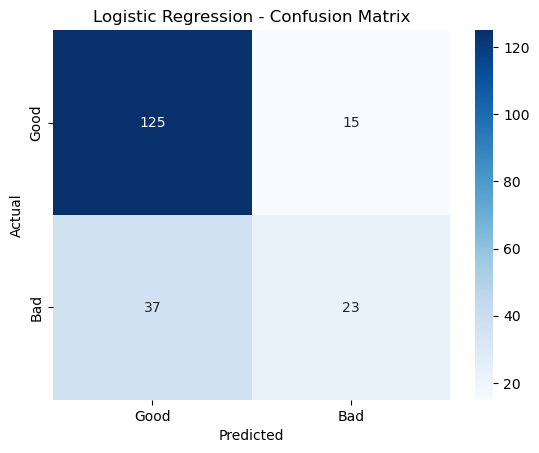

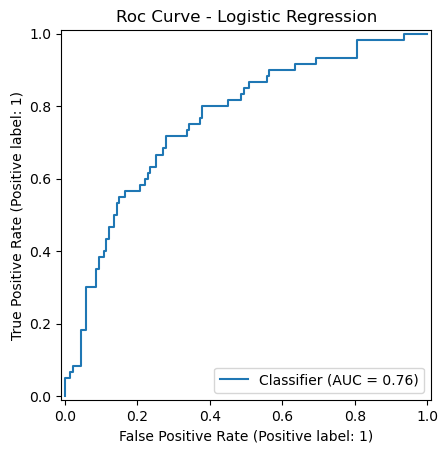

In [20]:
# evaluating the baseline model (log_reg)
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("visualisations/logistic_regression_confusion_matrix.png")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Roc Curve - Logistic Regression")
plt.savefig("visualisations/logistic_regression_roc_curve.png")
plt.show()

For a lender, missing defaulters is costlier than rejecting good clients.\
The model is better at identifying good borrowers (recall=0.89).\
However, it is much worse at identifying bad ones (recall=0.38).

AUC-ROC (RF): 0.8010714285714287
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       140
           1       0.56      0.70      0.62        60

    accuracy                           0.74       200
   macro avg       0.71      0.73      0.71       200
weighted avg       0.77      0.74      0.75       200



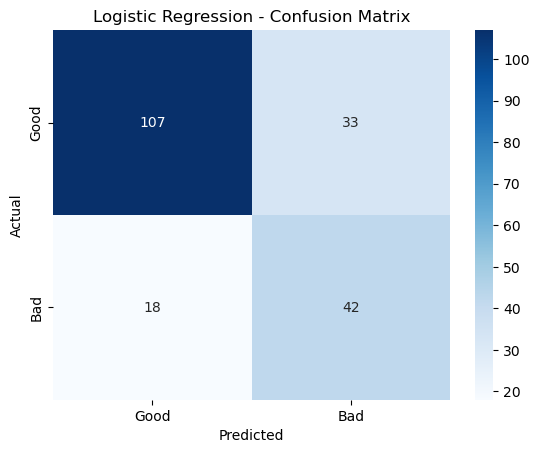

In [21]:
# instantiating a second model for comparison (RandomForest)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("AUC-ROC (RF):", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("visualisations/untuned_random_forest_confusion_matrix.png")
plt.show()

Using `class_weight="balanced"` ensures the minority class of defaults is not ignored.

AUC-ROC for rf is higher.\
Recall for defaults is much better in rf as well (0.38 -> 0.70).\
Precision has fallen for defaults (0.61 -> 0.56).

In [22]:
# adjusting hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                    param_grid, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_rf = grid.best_estimator_

Best Params: {'max_depth': 8, 'n_estimators': 100}
Best CV AUC: 0.7865327380952382


AUC-ROC (best_RF): 0.805
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       140
           1       0.61      0.63      0.62        60

    accuracy                           0.77       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.77      0.77      0.77       200



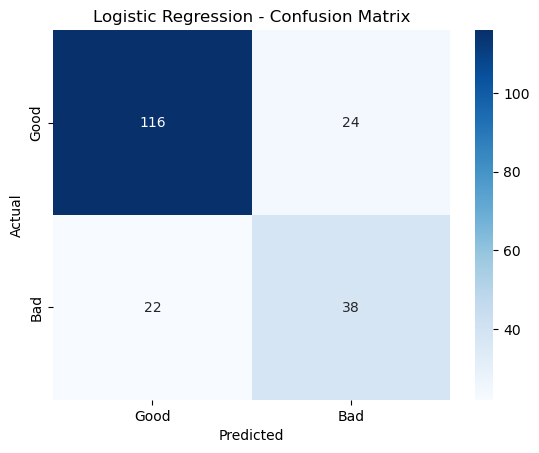

In [23]:
# evaluating adjusted rf (best_rf)
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("AUC-ROC (best_RF):", roc_auc_score(y_test, y_proba_best_rf))
print(classification_report(y_test, y_pred_best_rf))

cm = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("visualisations/tuned_random_forest_confusion_matrix.png")
plt.show()

Recall is improved, and precision is still manageable.\
Will proceed with best_rf from here on.

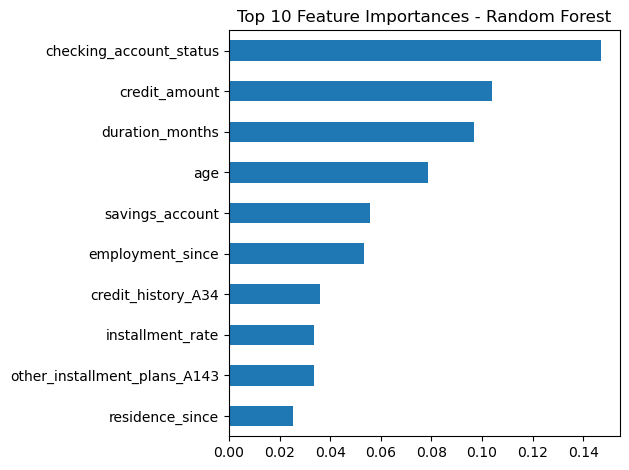

In [24]:
# visualising feature importances
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("visualisations/feature_importances.png")
plt.show()

`checking_account_status` is the most important feature. Thats odd, no?

Edit: `checking_account_status` singly contributes the most to removing impurities, hence it's position

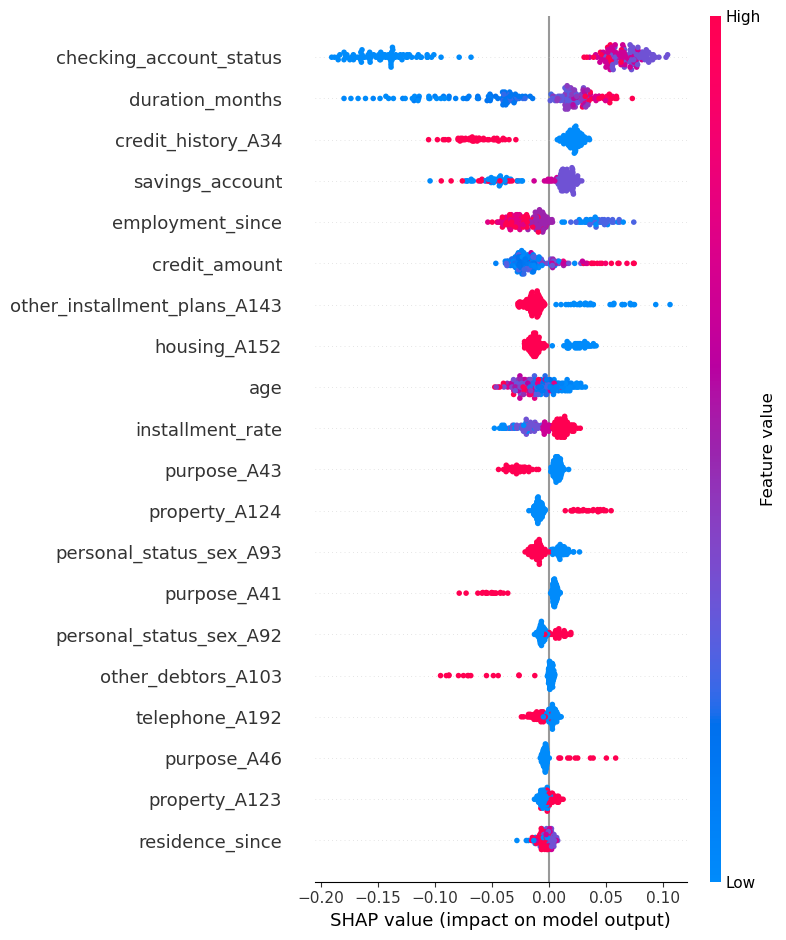

<Figure size 640x480 with 0 Axes>

In [26]:
# using SHAP
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# summary plot (shows both importance and direction of effect)
shap.summary_plot(shap_values[:, :, 1], X_test)